In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
FIGURE_DIR = './plots/'

In [3]:
import os
import pandas as pd

data_dir = './qPCR_data/'
files = os.listdir(data_dir)

dfs = {}

for file in files:
    if file.endswith('.csv'):
        file_path = os.path.join(data_dir, file)
        plate = file.split('.csv')[0]
        try:
            df = pd.read_csv(file_path, index_col = 0).reset_index(drop=True)
            dfs[plate] = df
        except Exception as e:
            print(f"Failed to read {file}: {e}")
    else:
        print(f"Skipping non-CSV or system file: {file}")

In [4]:
# remove empty wells
for key, df in dfs.items():
    dfs[key] = df.dropna(subset=['Cq']).copy()

In [5]:
def add_to_platemap(platemap: dict, row: str, gene1: str, gene2: str):
    """
    Add entries to an existing platemap for a given row with two genes,
    alternating every 3 wells.

    Parameters:
    - platemap (dict): Existing dictionary to add entries to
    - row (str): Row letter (e.g. 'A')
    - gene1 (str): First gene name
    - gene2 (str): Second gene name

    Modifies:
    - platemap (dict): Adds new entries in-place
    """
    genes = [gene1, gene2]

    for i in range(1, 13):  # 12 wells per row
        gene = genes[(i - 1) // 3 % 2]  # Switch every 3 wells
        well = f"{row}{i:02}"
        platemap[well] = gene


In [6]:
platemap = {}
add_to_platemap(platemap, 'A', 'GAPDH', 'DAZAP2')
add_to_platemap(platemap, 'B', 'COMP', 'TRPV2')
add_to_platemap(platemap, 'C', 'CHMP1A', 'NCOR2')
add_to_platemap(platemap, 'D', 'SLC7A5', 'TMEM204')
add_to_platemap(platemap, 'E', 'SMAD7', 'RPL7L1')
add_to_platemap(platemap, 'F', 'CDC45', 'SETDB2')
add_to_platemap(platemap, 'G', 'TYRO3', 'CANT1')
add_to_platemap(platemap, 'H', 'NCALD', 'GAPDH-B')

dfs['Plate_1']['gene'] = dfs['Plate_1']['Well'].map(platemap)
dfs['Plate_2']['gene'] = dfs['Plate_2']['Well'].map(platemap)
dfs['Plate_3']['gene'] = dfs['Plate_3']['Well'].map(platemap)
dfs['Plate_4']['gene'] = dfs['Plate_4']['Well'].map(platemap)

platemap5 = {}

add_to_platemap(platemap5, 'A', 'GAPDH', 'GAPDH')
add_to_platemap(platemap5, 'B', 'RASGRP1', 'RASGRP1')
add_to_platemap(platemap5, 'C', 'GALNS', 'GALNS')
add_to_platemap(platemap5, 'D', 'GAPDH', 'GAPDH')
add_to_platemap(platemap5, 'E', 'RASGRP1', 'RASGRP1')
add_to_platemap(platemap5, 'F', 'GALNS', 'GALNS')
dfs['Plate_5']['gene'] = dfs['Plate_5']['Well'].map(platemap5)

In [7]:
well_map = {
    '01': 1,
    '02': 2,
    '03': 3,
    '04': 1,
    '05': 2,
    '06': 3,
    '07': 1,
    '08': 2,
    '09': 3,
    '10': 1,
    '11': 2,
    '12': 3,
}

for df in dfs.values():
    df['rep'] = df['Well'].str[-2:].map(well_map)

In [8]:
plate1_sample_map = {
    '01': 'Young untreated',
    '02': 'Young untreated',
    '03': 'Young untreated',
    '04': 'Young untreated',
    '05': 'Young untreated',
    '06': 'Young untreated',
    '07': 'Old untreated',
    '08': 'Old untreated',
    '09': 'Old untreated',
    '10': 'Old untreated',
    '11': 'Old untreated',
    '12': 'Old untreated',
}
dfs['Plate_1']['sample'] = dfs['Plate_1']['Well'].str[-2:].map(plate1_sample_map)

plate2_sample_map = {
    '01': 'Old + vector control',
    '02': 'Old + vector control',
    '03': 'Old + vector control',
    '04': 'Old + vector control',
    '05': 'Old + vector control',
    '06': 'Old + vector control',
    '07': 'Old + SNHG18',
    '08': 'Old + SNHG18',
    '09': 'Old + SNHG18',
    '10': 'Old + SNHG18',
    '11': 'Old + SNHG18',
    '12': 'Old + SNHG18',
}
dfs['Plate_2']['sample'] = dfs['Plate_2']['Well'].str[-2:].map(plate2_sample_map)

plate3_sample_map = {
    '01': 'Young + LMO7-AS1',
    '02': 'Young + LMO7-AS1',
    '03': 'Young + LMO7-AS1',
    '04': 'Young + LMO7-AS1',
    '05': 'Young + LMO7-AS1',
    '06': 'Young + LMO7-AS1',
    '07': 'Old + vector control',
    '08': 'Old + vector control',
    '09': 'Old + vector control',
    '10': 'Old + vector control',
    '11': 'Old + vector control',
    '12': 'Old + vector control',
}
dfs['Plate_3']['sample'] = dfs['Plate_3']['Well'].str[-2:].map(plate3_sample_map)

plate4_sample_map = {
    '01': 'Old + SNHG18',
    '02': 'Old + SNHG18',
    '03': 'Old + SNHG18',
    '04': 'Old + SNHG18',
    '05': 'Old + SNHG18',
    '06': 'Old + SNHG18',
    '07': 'Young + vector control',
    '08': 'Young + vector control',
    '09': 'Young + vector control',
    '10': 'Young + vector control',
    '11': 'Young + vector control',
    '12': 'Young + vector control',
}
dfs['Plate_4']['sample'] = dfs['Plate_4']['Well'].str[-2:].map(plate4_sample_map)

def assign_condition_plate5(row):
    r, c = row['Well'][0],  int(row['Well'][1:])
    
    if r in 'ABC':
        if 1 <= c <= 3:
            return 'Young untreated'
        elif 4 <= c <= 6:
            return 'Old untreated'
        elif 7 <= c <= 9:
            return 'Young + LMO7-AS1'
        elif 10 <= c <= 12:
            return 'Young + vector control'
    elif r in 'DEF':
        if 1 <= c <= 3:
            return 'Old + SNHG18'
        elif 4 <= c <= 6:
            return 'Old + vector control'
    return 'Unknown'  # fallback if outside known range

dfs['Plate_5']['sample'] = dfs['Plate_5'].apply(assign_condition_plate5, axis=1)

In [9]:
arr = []
for df in dfs.values():
    temp_df = df[['Well', 'Cq', 'Cq Mean', 'gene', 'rep', 'sample']].copy()

    # Assuming your DataFrame is named df and has the following columns:
    # 'Well', 'Cq', 'Cq Mean', 'gene', 'rep', 'sample'
    
    # Initialize columns
    temp_df['delta_ct_vs_GAPDH'] = np.nan
    # temp_df['fold_change_vs_GAPDH'] = np.nan
    
    # Group by sample and rep
    for (sample, rep), group in temp_df.groupby(['sample', 'rep']):
        # Get GAPDH Cq Mean for this group
        gapdh_rows = group[group['gene'] == 'GAPDH']
        
        if gapdh_rows.empty:
            continue  # Skip if GAPDH is missing for this group
        
        # Use the mean GAPDH Cq if multiple entries (e.g., if technical replicates exist)
        gapdh_cq = gapdh_rows['Cq Mean'].mean()
        
        # Create a mask for the current group
        mask = (temp_df['sample'] == sample) & (temp_df['rep'] == rep)
        
        # Compute delta Ct
        temp_df.loc[mask, 'delta_ct_vs_GAPDH'] = temp_df.loc[mask, 'Cq Mean'] - gapdh_cq
        
        # Compute fold change
        # temp_df.loc[mask, 'fold_change_vs_GAPDH'] = 2 ** (-temp_df.loc[mask, 'delta_ct_vs_GAPDH'])
    
    arr.append(temp_df)

qpcr_df = pd.concat(arr)

In [10]:
cmap = {
    'Young untreated' : sns.color_palette("tab20")[6],
    'Young + vector control' :sns.color_palette("tab20")[7],
    'Old untreated' :sns.color_palette("tab20")[4],
    'Old + vector control' :sns.color_palette("tab20")[5],
    'Young + LMO7-AS1': sns.color_palette("tab20")[12],
    'Old + SNHG18': "#98bf64"
}

/tmp/ipykernel_178630/2921860398.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['gene'] = pd.Categorical(df_plot['gene'], categories=old_genes, ordered=True)
/tmp/ipykernel_178630/2921860398.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['sample'] = pd.Categorical(df_plot['sample'], categories=samples, ordered=True)
/tmp/ipykernel_178630/2921860398.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/home/dpaysan/proje

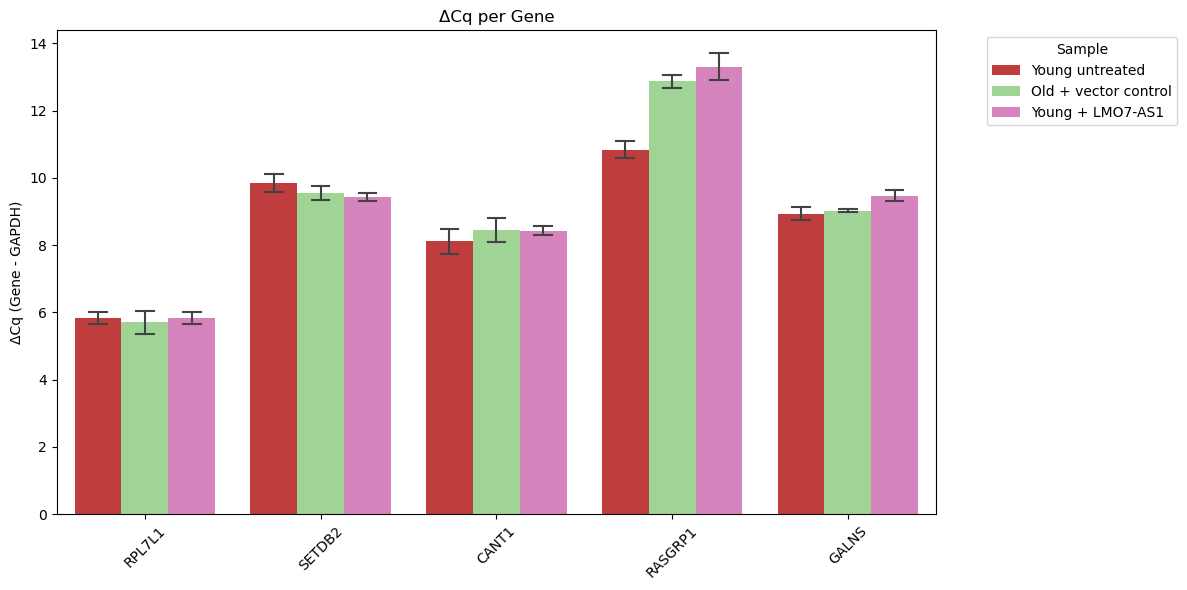

In [11]:
samples = ['Young untreated', 'Old + vector control', 'Young + LMO7-AS1']
old_genes = ['RPL7L1', 'SETDB2', 'CANT1', 'RASGRP1', 'GALNS']

# Filter data
data = qpcr_df[qpcr_df['sample'].isin(samples)]
df_plot = data[data['gene'].isin(old_genes)]

# Set categorical order for genes and samples
df_plot['gene'] = pd.Categorical(df_plot['gene'], categories=old_genes, ordered=True)
df_plot['sample'] = pd.Categorical(df_plot['sample'], categories=samples, ordered=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='gene',
    y='delta_ct_vs_GAPDH',
    hue='sample',
    ci='sd',  
    capsize=0.1,
    errwidth=1.5,
    palette=cmap,
    order=old_genes,
    hue_order=samples
)

plt.ylabel("ΔCq (Gene - GAPDH)")
plt.title("ΔCq per Gene")
plt.xlabel(None)
plt.xticks(rotation=45)
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Figure 5e (LMO7)


/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

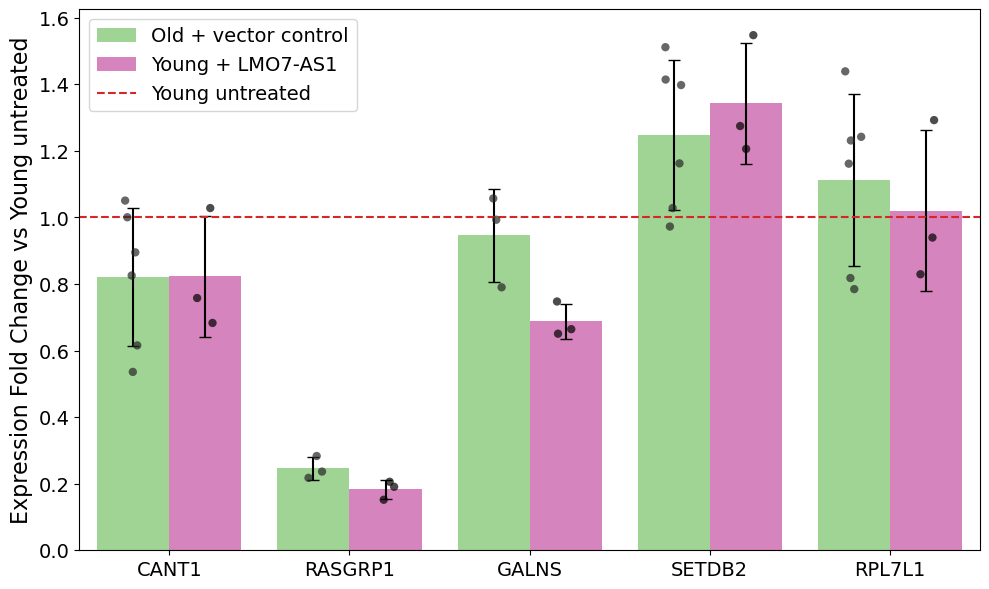

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# -----------------------------
# Configuration
# -----------------------------
baseline = 'Young untreated'
samples = ['Old + vector control', 'Young + LMO7-AS1']
sample_order = [baseline] + samples
non_baseline_samples = [s for s in sample_order if s != baseline]
old_genes = ['CANT1', 'RASGRP1', 'GALNS', 'SETDB2', 'RPL7L1']

# -----------------------------
# Subset dataframe
# -----------------------------
df = qpcr_df[
    (qpcr_df['sample'].isin(sample_order)) &
    (qpcr_df['gene'].isin(old_genes))
].copy()

# -----------------------------
# Compute ΔΔCq and fold change per replicate
# -----------------------------
baseline_df = (
    df[df['sample'] == baseline][['gene', 'rep', 'delta_ct_vs_GAPDH']]
    .rename(columns={'delta_ct_vs_GAPDH': 'baseline_deltaCq'})
)

df = df.merge(baseline_df, on=['gene', 'rep'], how='left')
df['delta_delta_Cq'] = df['delta_ct_vs_GAPDH'] - df['baseline_deltaCq']
df['fold_change'] = 2 ** (-df['delta_delta_Cq'])

# -----------------------------
# Filter out baseline for plotting
# -----------------------------
df_plot = df[df['sample'] != baseline].copy()

summary = (
    df_plot.groupby(['gene', 'sample'])['fold_change']
    .agg(['mean', 'std'])
    .reset_index()
)

# -----------------------------
# Extract baseline color from cmap
# -----------------------------
baseline_color = cmap[baseline]
plot_palette = {k: v for k, v in cmap.items() if k != baseline}

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Bars (mean, no built-in error bars)
sns.barplot(
    data=summary,
    x='gene',
    y='mean',
    hue='sample',
    hue_order=non_baseline_samples,
    order=old_genes,
    palette=plot_palette,
    errorbar=None,
    ax=ax
)

# SD error bars
n_hue = len(non_baseline_samples)
bar_width = 0.8 / n_hue

for i, gene in enumerate(old_genes):
    for j, sample in enumerate(non_baseline_samples):
        row = summary[(summary['gene'] == gene) & (summary['sample'] == sample)]
        if len(row) == 0:
            continue
        mean_val = row['mean'].values[0]
        std_val = row['std'].values[0]
        x_pos = i - 0.4 + bar_width / 2 + j * bar_width
        ax.errorbar(
            x=x_pos, y=mean_val, yerr=std_val,
            fmt='none', ecolor='black', capsize=4, linewidth=1.5
        )

# Individual data points
sns.stripplot(
    data=df_plot,
    x='gene',
    y='fold_change',
    hue='sample',
    hue_order=non_baseline_samples,
    order=old_genes,
    dodge=True,
    color='black',
    size=6,
    alpha=0.7,
    legend=False,
    ax=ax
)

# Baseline reference line (colored dashed)
ax.axhline(1, color=baseline_color, linestyle='--', linewidth=1.5)

# -----------------------------
# Legend: bar groups + dashed baseline
# -----------------------------
bar_handles, bar_labels = ax.get_legend_handles_labels()
bar_handles = bar_handles[:n_hue]
bar_labels = bar_labels[:n_hue]

baseline_handle = Line2D(
    [0], [0],
    color=baseline_color,
    linestyle='--',
    linewidth=1.5,
    label=baseline
)

ax.legend(
    handles=bar_handles + [baseline_handle],
    labels=bar_labels + [baseline],
    fontsize=14
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_ylabel('Expression Fold Change vs Young untreated', fontsize=16)
ax.set_xlabel(None)
ax.tick_params(axis='both', labelsize=14)
plt.tight_layout()
fig.savefig(f"./fig5e_1.svg", bbox_inches='tight')
plt.show()

/tmp/ipykernel_1039919/1710248626.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['gene'] = pd.Categorical(df_plot['gene'], categories=young_genes, ordered=True)
/tmp/ipykernel_1039919/1710248626.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['sample'] = pd.Categorical(df_plot['sample'], categories=samples, ordered=True)
/tmp/ipykernel_1039919/1710248626.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel

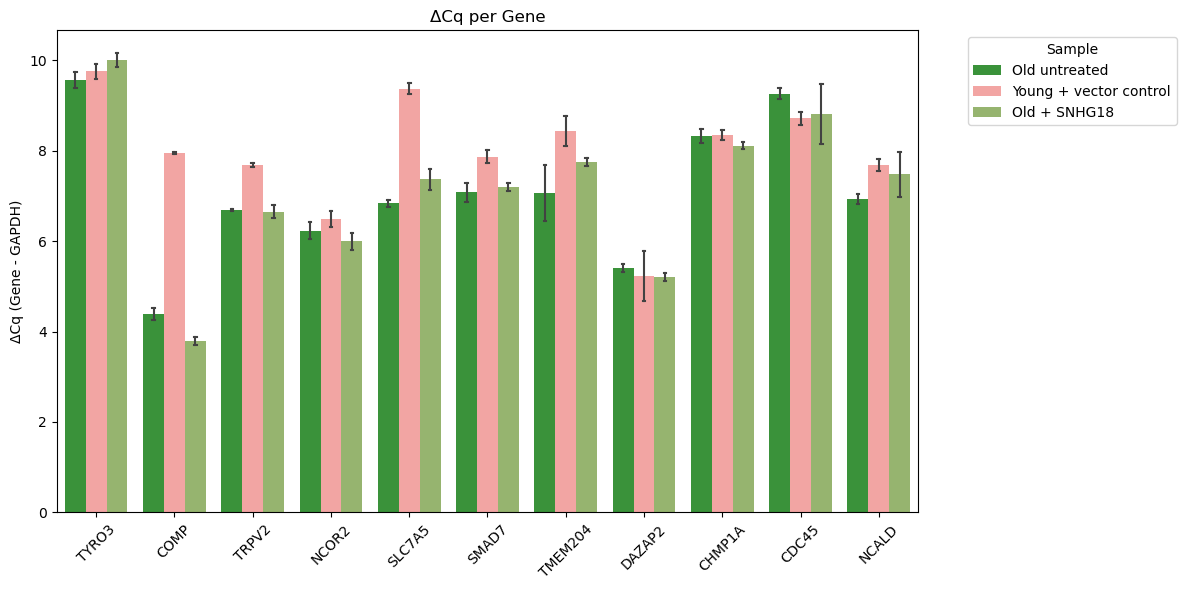

In [20]:
samples = ['Old untreated', 'Young + vector control', 'Old + SNHG18']
young_genes = [  'TYRO3',  'COMP',  'TRPV2', 'NCOR2', 'SLC7A5', 'SMAD7',  'TMEM204', 'DAZAP2','CHMP1A', 'CDC45', 'NCALD', ]

# Filter data
data = qpcr_df[qpcr_df['sample'].isin(samples)]
df_plot = data[data['gene'].isin(young_genes)]

# Set categorical order for genes and samples
df_plot['gene'] = pd.Categorical(df_plot['gene'], categories=young_genes, ordered=True)
df_plot['sample'] = pd.Categorical(df_plot['sample'], categories=samples, ordered=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='gene',
    y='delta_ct_vs_GAPDH',
    hue='sample',
    ci='sd',  
    capsize=0.1,
    errwidth=1.5,
    palette=cmap,
    order=young_genes,
    hue_order=samples
)

plt.ylabel("ΔCq (Gene - GAPDH)")
plt.title("ΔCq per Gene")
plt.xlabel(None)
plt.xticks(rotation=45)
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Figure 5e (SNHG18)

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

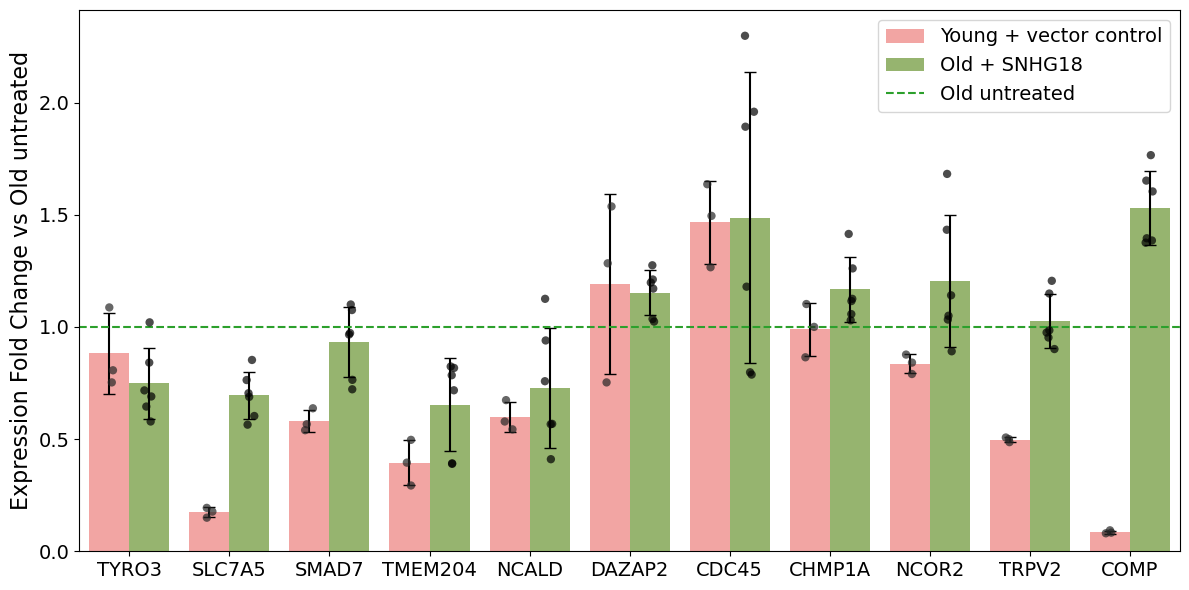

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# -----------------------------
# Configuration
# -----------------------------
baseline = 'Old untreated'
samples = ['Young + vector control', 'Old + SNHG18']
sample_order = [baseline] + samples
non_baseline_samples = [s for s in sample_order if s != baseline]
young_genes = ['TYRO3', 'SLC7A5', 'SMAD7', 'TMEM204', 'NCALD',
               'DAZAP2', 'CDC45', 'CHMP1A', 'NCOR2', 'TRPV2', 'COMP']

# -----------------------------
# Subset dataframe
# -----------------------------
df = qpcr_df[
    (qpcr_df['sample'].isin(sample_order)) &
    (qpcr_df['gene'].isin(young_genes))
].copy()

# -----------------------------
# Compute ΔΔCq and fold change per replicate
# -----------------------------
baseline_df = (
    df[df['sample'] == baseline][['gene', 'rep', 'delta_ct_vs_GAPDH']]
    .rename(columns={'delta_ct_vs_GAPDH': 'baseline_deltaCq'})
)

df = df.merge(baseline_df, on=['gene', 'rep'], how='left')
df['delta_delta_Cq'] = df['delta_ct_vs_GAPDH'] - df['baseline_deltaCq']
df['fold_change'] = 2 ** (-df['delta_delta_Cq'])

# -----------------------------
# Filter out baseline for plotting
# -----------------------------
df_plot = df[df['sample'] != baseline].copy()

summary = (
    df_plot.groupby(['gene', 'sample'])['fold_change']
    .agg(['mean', 'std'])
    .reset_index()
)

# -----------------------------
# Extract baseline color from cmap
# -----------------------------
baseline_color = cmap[baseline]
plot_palette = {k: v for k, v in cmap.items() if k != baseline}

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Bars (mean, no built-in error bars)
sns.barplot(
    data=summary,
    x='gene',
    y='mean',
    hue='sample',
    hue_order=non_baseline_samples,
    order=young_genes,
    palette=plot_palette,
    errorbar=None,
    ax=ax
)

# SD error bars
n_hue = len(non_baseline_samples)
bar_width = 0.8 / n_hue

for i, gene in enumerate(young_genes):
    for j, sample in enumerate(non_baseline_samples):
        row = summary[(summary['gene'] == gene) & (summary['sample'] == sample)]
        if len(row) == 0:
            continue
        mean_val = row['mean'].values[0]
        std_val = row['std'].values[0]
        x_pos = i - 0.4 + bar_width / 2 + j * bar_width
        ax.errorbar(
            x=x_pos, y=mean_val, yerr=std_val,
            fmt='none', ecolor='black', capsize=4, linewidth=1.5
        )

# Individual data points
sns.stripplot(
    data=df_plot,
    x='gene',
    y='fold_change',
    hue='sample',
    hue_order=non_baseline_samples,
    order=young_genes,
    dodge=True,
    color='black',
    size=6,
    alpha=0.7,
    legend=False,
    ax=ax
)

# Baseline reference line (colored dashed)
ax.axhline(1, color=baseline_color, linestyle='--', linewidth=1.5)

# -----------------------------
# Legend: bar groups + dashed baseline
# -----------------------------
bar_handles, bar_labels = ax.get_legend_handles_labels()
bar_handles = bar_handles[:n_hue]
bar_labels = bar_labels[:n_hue]

baseline_handle = Line2D(
    [0], [0],
    color=baseline_color,
    linestyle='--',
    linewidth=1.5,
    label=baseline
)

ax.legend(
    handles=bar_handles + [baseline_handle],
    labels=bar_labels + [baseline],
    fontsize=14
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_ylabel('Expression Fold Change vs Old untreated', fontsize=16)
ax.set_xlabel(None)
ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(f"./fig5e_2.svg", bbox_inches='tight')
plt.show()